## COVID19 Data Analysis & Epidemic Modelling 

Idea being to use real COVID19 data to analyse how the pandemic unfolded across different countries, then build epidemic models to stimulate intervention stratergies like vaccinations and lockdowns

Goal for today is to load the data and start analysing it

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("imports complete")

imports complete


In [9]:
df = pd.read_csv('../data/owid-covid-data.csv')
print(df.shape)

(429435, 67)


In [10]:
print(df.head())

  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN            

In [12]:
print(df.columns)

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  str    
 1   continent                                   402910 non-null  str    
 2   location                                    429435 non-null  str    
 3   date                                        429435 non-null  str    
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 10  total_c

## 2. Filtering the Data

In [16]:
df_filtered = df[['location', 'date', 'new_cases_smoothed', 'new_deaths_smoothed', 'total_cases', 'total_deaths', 'people_vaccinated_per_hundred', 'population']]
print(df_filtered.shape)

(429435, 8)


In [26]:
df_filtered['location'].nunique()

255

In [27]:
print(df_filtered['location'].unique()[:20])

<StringArray>
[        'Afghanistan',              'Africa',             'Albania',
             'Algeria',      'American Samoa',             'Andorra',
              'Angola',            'Anguilla', 'Antigua and Barbuda',
           'Argentina',             'Armenia',               'Aruba',
                'Asia',           'Australia',             'Austria',
          'Azerbaijan',             'Bahamas',             'Bahrain',
          'Bangladesh',            'Barbados']
Length: 20, dtype: str


## 3. Filtering to Selected Countries

In [31]:
countries = ['United Kingdom', 'United States', 'India', 'Brazil', 'Germany']
df_countries = df_filtered[df_filtered['location'].isin(countries)]
print(df_countries.shape)

(8378, 8)


## 4. New Cases Over Time by Country

<Axes: xlabel='date', ylabel='new_cases_smoothed'>

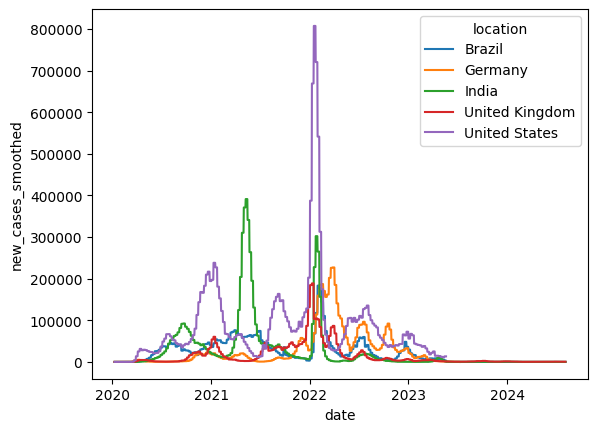

In [33]:
df_countries['date'] = pd.to_datetime(df_countries['date'])
sns.lineplot(data=df_countries, x='date', y='new_cases_smoothed', hue='location')

### Observation
The largest spike occurs in early 2022 (Omicron variant) rather than 2020 when 
lockdowns were first imposed. This suggests lockdown measures were effective at 
suppressing transmission in 2020. The 2022 spike coincided with the highly 
transmissible Omicron variant emerging alongside lifted restrictions.

Note: 2020 case counts are likely underestimates due to limited testing capacity.

## 5. Deaths Over Time by Country

<Axes: xlabel='date', ylabel='new_deaths_smoothed'>

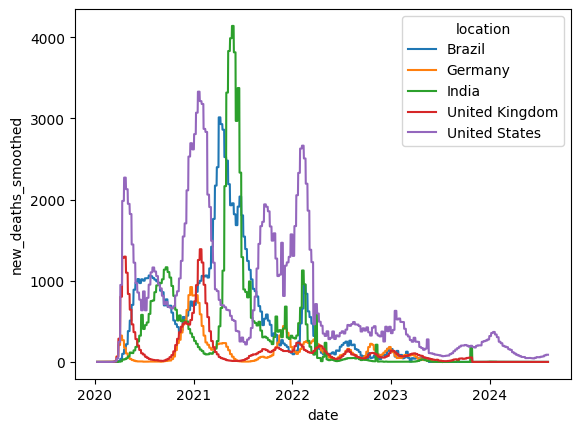

In [34]:
sns.lineplot(data=df_countries, x='date', y='new_deaths_smoothed', hue='location')

The largest spike occured in 2021 in India which was when they were hit with the Delta wave. However, India's population is 1.4billion so number of deaths may look misleading proportionally. The US seemed to have multiple peaks and this could be due to the different policy responses across the different states. If we look at deaths vs cases it is evident that the huge spike in cases in the US in 2022 didn't spike nearly as many deaths suggesting that the vaccines were working. 

## 6. Normalising by Population — Deaths per Million
Raw death counts are misleading when countries have vastly different population sizes.
Dividing by population gives a fairer comparison.

<Axes: xlabel='date', ylabel='deaths_per_million'>

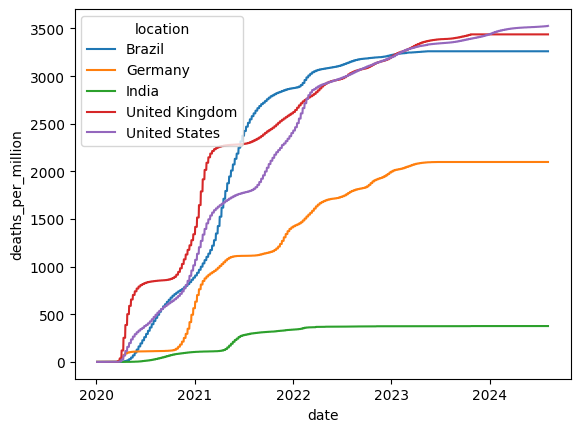

In [35]:
df_countries['deaths_per_million'] = df_countries['total_deaths'] / df_countries['population'] * 1000000
sns.lineplot(data=df_countries, x='date', y='deaths_per_million', hue='location')

Using deaths_per_million has changed the story completely. India now has by far the lowest amount of deaths - probably due to a much younger population but also possible underreporting of deaths in rural areas. On the otherhand the UK and US had the highest amount of deaths - most likely due to having older populations on average and higher obesity rates (a major COVID19 risk factor)

## 7. Vaccination Rates Over Time

<Axes: xlabel='date', ylabel='people_vaccinated_per_hundred'>

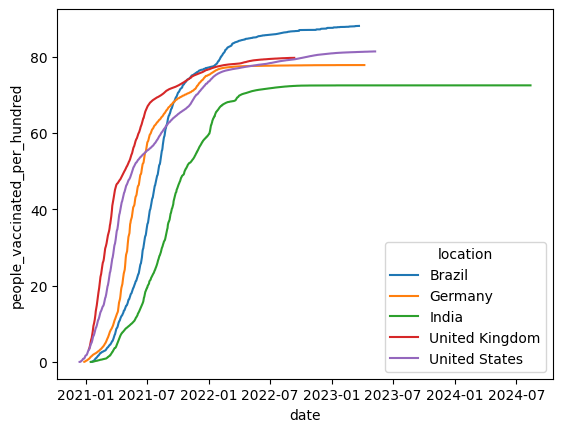

In [36]:
sns.lineplot(data=df_countries, x='date', y='people_vaccinated_per_hundred', hue='location')

The UK seemed to have the quickest distribution of the vaccine whilst India took more time however all countries managed to vaccinate more than 70% of their population which considerably slowed down the number of cases and deaths of COVID19.


## 8. Vaccine Effect — Cases vs Deaths Decoupling
The most compelling evidence for vaccine effectiveness is the decoupling of cases 
and deaths after mass vaccination. We expect to see deaths stop following cases 
once vaccination rates get high enough.

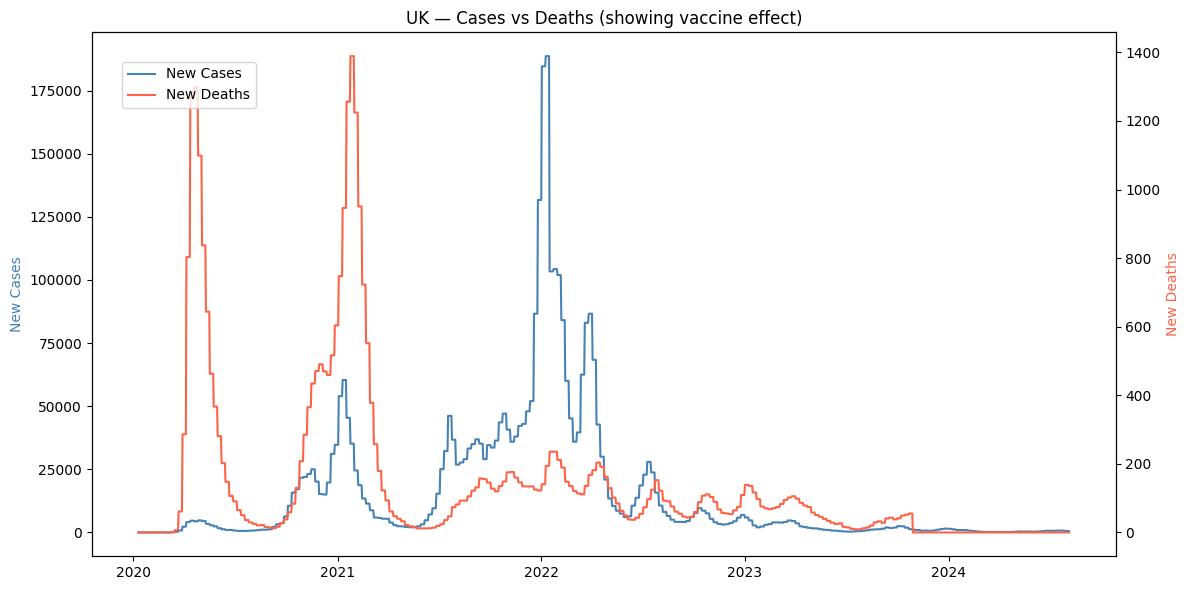

In [37]:
fig, ax1 = plt.subplots(figsize=(12, 6))

uk = df_countries[df_countries['location'] == 'United Kingdom']

ax1.plot(uk['date'], uk['new_cases_smoothed'], color='steelblue', label='New Cases')
ax1.set_ylabel('New Cases', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(uk['date'], uk['new_deaths_smoothed'], color='tomato', label='New Deaths')
ax2.set_ylabel('New Deaths', color='tomato')

plt.title('UK — Cases vs Deaths (showing vaccine effect)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

The vaccine effect occurs mid 2021 when despite the surge in new cases, the new deaths stays low.